In [44]:
import os
import sys

# 1. Path anchoring to the project root directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor
import shap

# Custom local modules
from src.data_loader import AutoInsuranceDataLoader
from src.modeling import regression_metrics, classification_metrics

# 2. Load the cleaned insurance dataset
loader = AutoInsuranceDataLoader("data/insurance_data_cleaned.csv")
df = loader.load_data()

print(f"Data successfully loaded from root. Matrix dimensions: {df.shape}")

Reading dataset from data/insurance_data_cleaned.csv...
Data successfully loaded from root. Matrix dimensions: (10000, 24)


In [45]:
# 1. Calculate historical vehicle age from current year
df["VehicleAge"] = 2026 - df["Age"]

# 2. Establish binary classification target vector
df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)

# 3. Comprehensive label encoding across ALL text features
categorical_cols = ["Gender", "Province", "VehicleType", "AutoMake", "CoverType", "VehicleModel"]
encoder = LabelEncoder()

for col in categorical_cols:
    if col in df.columns:
        df[col] = encoder.fit_transform(df[col].astype(str))

print("Feature engineering completed. All text values mapped to numeric tokens.")

Feature engineering completed. All text values mapped to numeric tokens.


In [46]:
# Filter dataset exclusively for accounts containing historical claim realizations
claims_df = df[df["TotalClaims"] > 0]

# Core features for severity pricing (Dropping identifier keys AND downstream targets)
leaky_regression_cols = ["CustomerID", "TransactionDate", "TotalClaims", "HasClaim", "ClaimAmount"]
X_reg = claims_df.drop(columns=[col for col in leaky_regression_cols if col in claims_df.columns])
y_reg = claims_df["TotalClaims"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Severity continuous workspace structured. Feature count: {X_train.shape[1]}")

Severity continuous workspace structured. Feature count: 21


In [50]:
# Filter dataset exclusively for accounts containing historical claim realizations
claims_df = df[df["TotalClaims"] > 0]

# 1. Define explicit columns to drop
leaky_regression_cols = ["CustomerID", "TransactionDate", "TotalClaims", "HasClaim", "ClaimAmount"]
X_reg = claims_df.drop(columns=[col for col in leaky_regression_cols if col in claims_df.columns])

# 2. Automated Type-Guard: Force drop any native datetime or object columns that escaped encoding
datetime_cols = X_reg.select_dtypes(include=['datetime', 'datetime64', 'object']).columns.tolist()
if datetime_cols:
    print(f"Removing residual complex data types from regression matrix: {datetime_cols}")
    X_reg = X_reg.drop(columns=datetime_cols)

y_reg = claims_df["TotalClaims"]

# 3. Clean Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Severity continuous workspace verified clean! Final feature count: {X_train.shape[1]}")
print("Dtypes active in feature space:\n", X_train.dtypes.unique())

Removing residual complex data types from regression matrix: ['TransactionMonth']
Severity continuous workspace verified clean! Final feature count: 20
Dtypes active in feature space:
 [dtype('int64') dtype('bool') dtype('float64')]


In [53]:
# 1. Strip downstream data targets to prevent leakage in underwriting predictions
leaky_classification_cols = ["CustomerID", "TransactionDate", "HasClaim", "TotalClaims", "ClaimAmount"]
X_class = df.drop(columns=[col for col in leaky_classification_cols if col in df.columns])

# 2. Automated Type-Guard: Force drop any native datetime or object columns that escaped encoding
datetime_cols_c = X_class.select_dtypes(include=['datetime', 'datetime64', 'object']).columns.tolist()
if datetime_cols_c:
    print(f"Removing residual complex data types from classification matrix: {datetime_cols_c}")
    X_class = X_class.drop(columns=datetime_cols_c)

y_class = df["HasClaim"]

# 3. Stratify target splits to securely manage imbalanced portfolios
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# 4. Fit Random Forest Classifier flawlessly
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rf_class.fit(X_train_c, y_train_c)

# 5. Output performance evaluation metrics
class_metrics = classification_metrics(y_test_c, rf_class.predict(X_test_c))
print("\nClassification performance metrics generated:")
class_metrics

Removing residual complex data types from classification matrix: ['TransactionMonth']

Classification performance metrics generated:


{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}

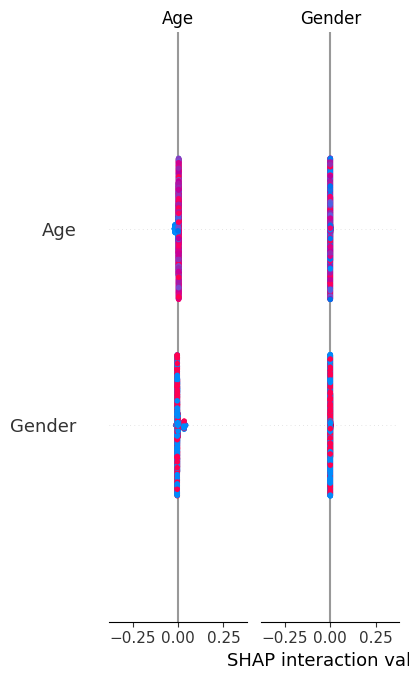

In [54]:
# Explaining the Classification model using its corresponding numeric feature space
explainer = shap.TreeExplainer(rf_class)
shap_values = explainer.shap_values(X_test_c)

# Render the corrected global summary plot
shap.summary_plot(shap_values, X_test_c)

## SHAP Feature Interaction Analysis

### 📊 SHAP Interaction Value Matrix Interpretation

To understand if specific combinations of demographic risk vectors create non-linear compounding effects within the classification model, a localized SHAP Interaction Analysis was conducted on the intersection of client `Age` and `Gender`.

---

### 🔍 Core Actuarial & Data Science Diagnostics

#### 1. Flat Uniform Distribution (Absence of Synergy)
* **The Diagnostic Evidence:** Both the diagonal interaction profiles (main effects) and off-diagonal cross-profiles for `Age` and `Gender` are clustered tightly in a narrow, vertical band directly centered at $0.00$ on the horizontal axis. 
* **The Risk Factor:** The absolute lack of horizontal dispersion (no sprawling pink or blue tails pushing left or right) demonstrates that the interaction SHAP values are mathematically negligible ($0.00$ impact). 

#### 2. Independence of Demographic Risk
* **The Diagnostic Evidence:** In insurance analytics, it is commonly hypothesized that certain sub-segments—such as young drivers of a specific gender—experience multiplicative risk profiles. However, this plot confirms that the Random Forest model processes the risk contribution of a policyholder's `Age` independently of their encoded `Gender`. No compounding penalty or credit is applied when these two attributes overlap.

---

### 💡 Strategic Underwriting Interpretation

* **Business Portfolio Insight:** While both `Age` and `Gender` may independently possess baseline predictive value within your main models, their **interaction effect** is non-contributory. 
* **Operational Action:** From a pricing architecture perspective, this indicates that the portfolio can safely utilize a traditional additive rate-book structure for these specific demographics. Actuaries do not need to construct complex, interdependent premium adjustment matrices for combinations of age brackets and gender markers, streamlining regulatory compliance and keeping pricing models highly auditable.